# Mod C - Week 1 - Linear Regression 1 Analysis
##### Include concepts such as linear regression with polynomial terms, interaction terms, multicollinearity, variance inflation factor and regression, and categorical and continuous features


The datasets wer previously cleaned and explored using EDA. In Week 1, we extend this analysis using regression-based methods.Although the ultimate goal of this project is binary classification (attack vs. normal), in Week 1  demonstrate regression methods for continuous variables to explore multicollinearity, polynomial features, and interaction effects.

## Imports and Load datasets from kaggle

In [1]:
## General libraries 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

### Libraries for train test split and models

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error


########  polynomial libraires
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor



  


## LOAD DATASETS and specific libraries
 
import kagglehub
import os

# DATASET 1 :  BETH cyberseurity dataset
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)
print(os.listdir(beth_dataset_path))
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)


# DATASET 2: Cybersecurity Dataset
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\23
['cybersecurity_attacks.csv', 'README.md']


# Dataset 1: BETH Cybersecurity dataset
#### (i) Exploratory Data analysis  

In [2]:

# Encode categorical features to numerical features using label encoder to allow regression modelling
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
# Verify and split the datset 
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)
#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")


#######################  Assign features and target ################################################################################3
# Features and target (using 'evil' as the target variable)Although the primary target (evil) is binary, 
# we focus on applying linear regression techniques on continuous features to understand model concepts like multicollinearity and interaction effects.
##################################################################################################################################
X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64
Shape of the DataFrame: (684646, 16)
numeric columns: 
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
categorical columns: 
 Index([], dtype='object')


####  View the training dataset 

In [3]:
X_train_beth.head()

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args
1060840,472.442379,7555,7555,7548,1001,4026531840,249,5,3,8,112473,1,0,183909
608882,914.843280,7282,7282,187,0,4026532217,94,11,257,28,48426,4,15,160353
56548,2886.683328,7369,7369,1317,0,4026531840,72,0,3,8,112473,1,0,186766
1071941,479.252498,7555,7555,7548,1001,4026531840,249,5,42,9,112473,3,-114,260097
695524,550.777799,7318,7318,7099,0,4026531840,82,9,1005,32,18441,4,0,225439


In [4]:
y_train_beth.head()

1060840    1
608882     0
56548      0
1071941    1
695524     0
Name: evil, dtype: int64

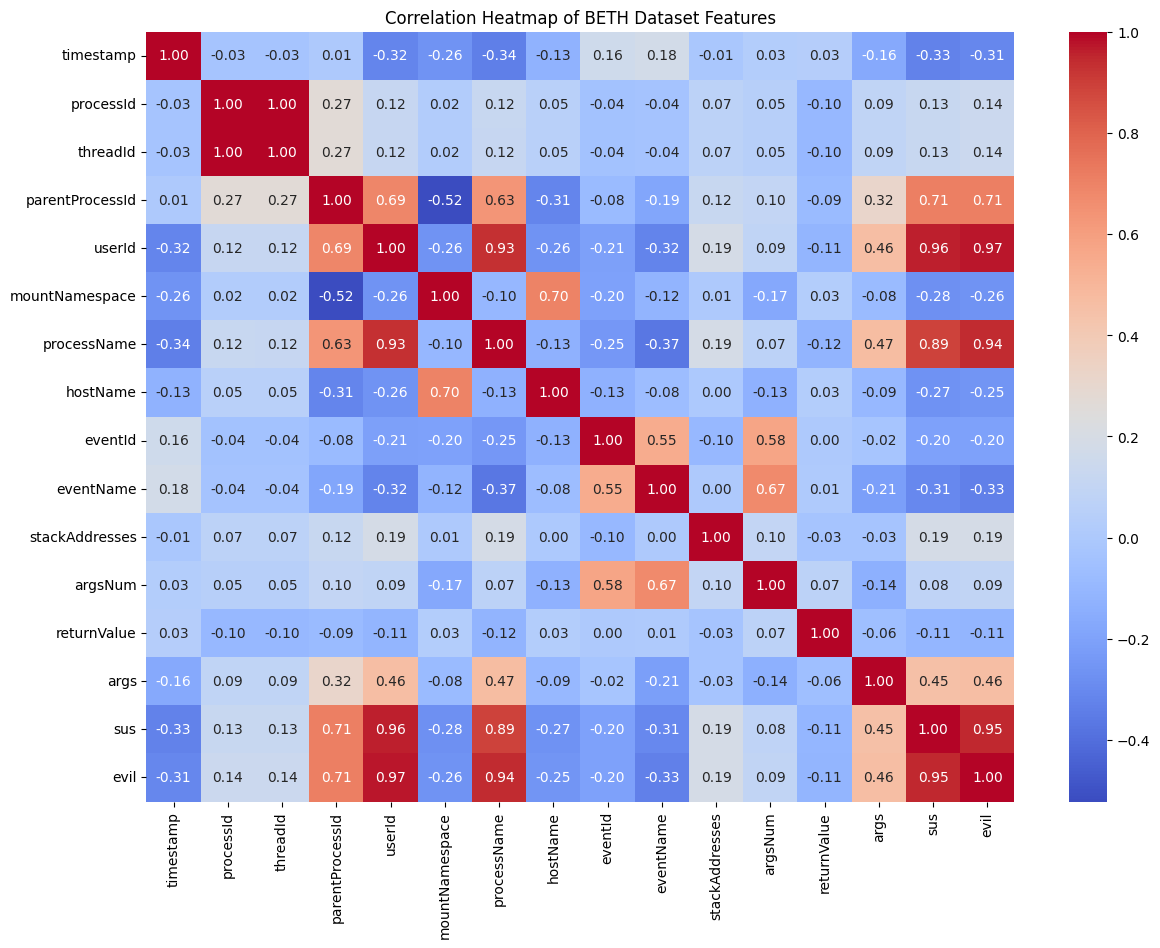

In [5]:
plt.figure(figsize=(14,10))
sns.heatmap(df_beth.corr(), cmap="coolwarm", annot=True, cbar=True,fmt=".2f")
plt.title("Correlation Heatmap of BETH Dataset Features")
plt.show()

#### (ii) Linear & Polynomial Regression , Multi collinearity

C:\Users\phxlab\AppData\Local\Temp\ipykernel_27584\819015910.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="coolwarm")


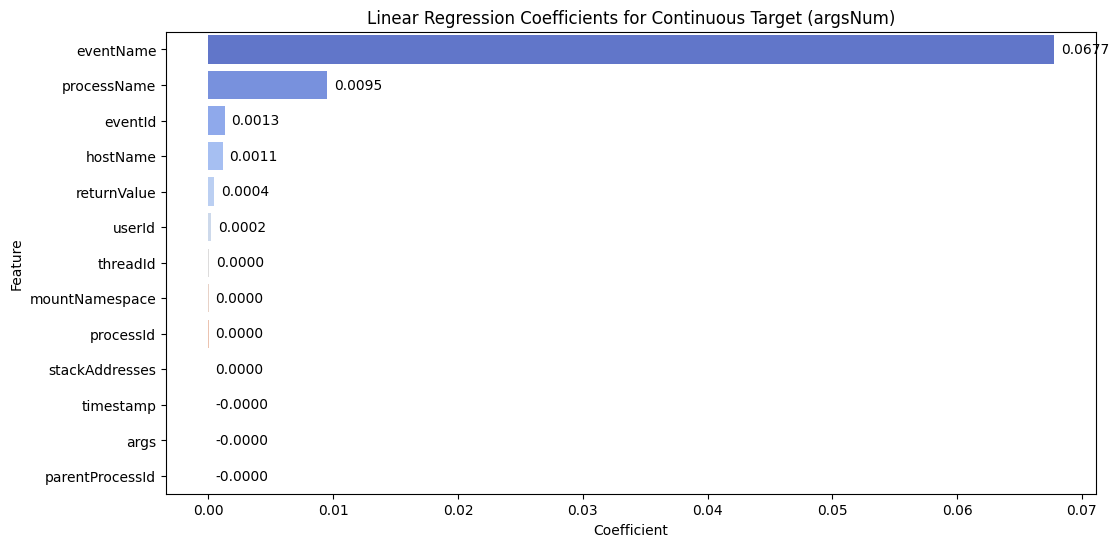

            Feature         VIF
0         timestamp    1.306202
1         processId  225.289913
2          threadId  225.146369
3   parentProcessId    2.351857
4            userId    9.489411
5    mountNamespace   58.281127
6       processName    8.485736
7          hostName    1.310794
8           eventId    1.498675
9         eventName    1.607949
10   stackAddresses    1.085163
11      returnValue    1.025242
12             args    1.343326
RMSE: 0.6816497243738686, MAE: 0.45242161109445034


In [10]:

# Linear regression with continous target
###################################Simple Linear Regression#########################################
y_continuous = df_beth['argsNum']
X_continuous = df_beth.drop(['argsNum','evil','sus'], axis=1)

lr_model = LinearRegression()
lr_model.fit(X_continuous, y_continuous)
y_pred = lr_model.predict(X_continuous)

# Collect coefficients into DataFrame
coef_df = pd.DataFrame({
    "Feature": X_continuous.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(12,6))
ax = sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="coolwarm")

# Annotate
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}", 
                (p.get_width(), p.get_y() + p.get_height()/2),
                xytext=(5,0), textcoords="offset points",
                ha="left", va="center")

plt.title("Linear Regression Coefficients for Continuous Target (argsNum)")
plt.show()
#######################Polynomial Terms##########################################
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X_continuous)

lr_poly_model = LinearRegression()
lr_poly_model.fit(X_poly, y_continuous)


###############################Multicollinearity########################################
##  Features with VIF > 5 (or 10) indicate high multicollinearity and may need to be removed or combined

X_numeric = X_continuous.select_dtypes(include=[np.number])
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]
print(vif_data)
###############################Model Evaluation###########################################################333

rmse = np.sqrt(mean_squared_error(y_continuous, y_pred))
mae = mean_absolute_error(y_continuous, y_pred)
print(f"RMSE: {rmse}, MAE: {mae}")


### Conclusion:

1. Applied linear regression with polynomial/interaction terms  by using argsNum (continuous) as the dependent variable, we explored polynomial terms, multicollinearity, and regression metrics.It helps to find feature relaitonships.

2. VIF revealed major multicollinearity issues (especially with processId, threadId, mountNamespace).

3. Regression metrics (RMSE ~0.68, MAE ~0.45) show that the  linear regression is not optimal for binary targets.

Since the primary project targets (evil, sus) are binary(0/1), logistic regression is more suitable for subsequent weeks, but this exercise demonstrates key regression concepts as required in the weekly progression.
 

# Dataset 2: Cybersecurity dataset
#### (i) Exploratory Data analysis  

In [9]:
#print(df_csa.columns.to_list())
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 'Device Information','Geo-location Data','Proxy Information','Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)
df_new_csa['Malware Indicators'].fillna('None Detected')
df_new_csa['Alerts/Warnings'].fillna('No Alert')

df_csa_encoded = df_new_csa.copy()

# Define categorical columns (assuming csa_categorical_columns is defined elsewhere)
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

# Convert Timestamp to datetime and verify
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
if df_csa_encoded['Timestamp'].dtype != 'datetime64[ns]':
    print("Warning: Timestamp column is not datetime64[ns]. Checking for issues...")
    print(df_csa_encoded['Timestamp'].head())  # Debug: Check the first few values
    df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with NaT if needed

# Extract time components
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode all categorical columns
label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Combine all numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number')

# Handle any remaining NaN values
df_features = df_features.fillna(0)


csa_numeric_columns=df_features.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(csa_numeric_columns.to_list())
print('\n')

csa_categorical_columns=df_features.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(csa_categorical_columns.to_list())

######################################################################################################


X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(df_features.drop(columns=['Anomaly Scores']), df_features['Anomaly Scores'], test_size=0.2, random_state=0)




Numeric columns in the dataset:

['Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts', 'Hour', 'Weekday', 'Month']


Categorical columns in the dataset:

[]


####  View the training dataset 

#### (ii) Linear & Polynomial Regression , Multi collinearity

C:\Users\phxlab\AppData\Local\Temp\ipykernel_27584\602014615.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=coef_csa_df, x="Coefficient", y="Feature", palette="coolwarm")


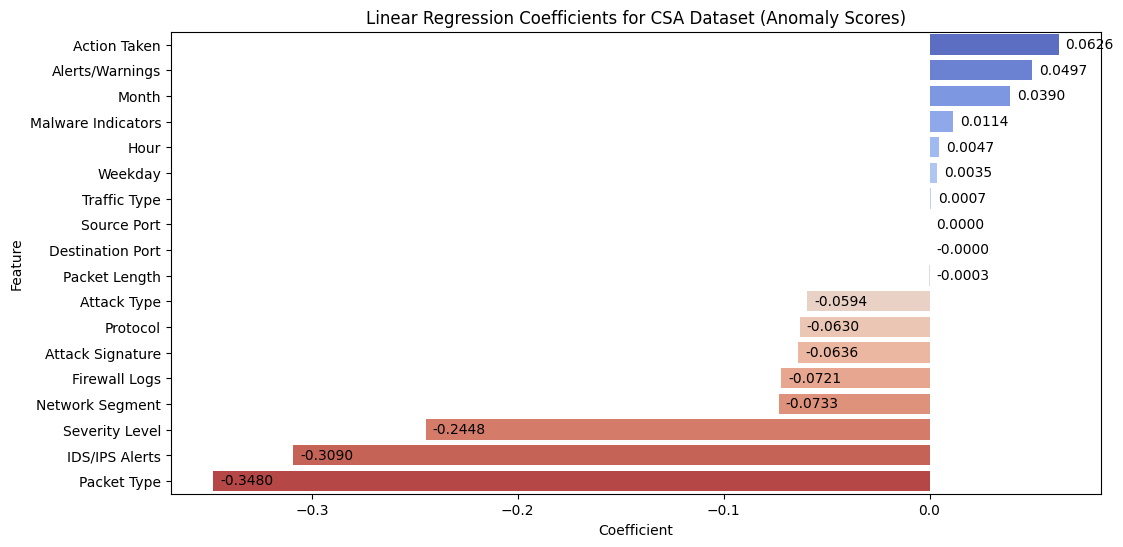

Polynomial regression fitted successfully!

Variance Inflation Factor (VIF) for CSA dataset:
               Feature       VIF
0          Source Port  3.762421
1     Destination Port  3.778313
2             Protocol  2.375916
3        Packet Length  4.073728
4          Packet Type  1.918787
5         Traffic Type  2.389641
6   Malware Indicators  1.938916
7      Alerts/Warnings  1.950554
8          Attack Type  2.379430
9     Attack Signature  1.927518
10        Action Taken  2.370311
11      Severity Level  2.389263
12     Network Segment  2.400960
13       Firewall Logs  1.940745
14      IDS/IPS Alerts  1.950717
15                Hour  3.472448
16             Weekday  3.011870
17               Month  4.103007

CSA Dataset Evaluation Metrics:
RMSE: 28.8503
MAE: 24.9762


In [11]:
# =============================================
# Linear Regression with CSA Dataset
# =============================================

# Define X and y
y_csa = df_features['Anomaly Scores']
X_csa = df_features.drop(columns=['Anomaly Scores'])

# ------------------ Simple Linear Regression ------------------
lr_model_csa = LinearRegression()
lr_model_csa.fit(X_csa, y_csa)
y_pred_csa = lr_model_csa.predict(X_csa)

# Collect coefficients
coef_csa_df = pd.DataFrame({
    "Feature": X_csa.columns,
    "Coefficient": lr_model_csa.coef_
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=coef_csa_df, x="Coefficient", y="Feature", palette="coolwarm")

# Annotate values
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}",
                (p.get_width(), p.get_y() + p.get_height()/2),
                xytext=(5, 0), textcoords="offset points",
                ha="left", va="center")

plt.title("Linear Regression Coefficients for CSA Dataset (Anomaly Scores)")
plt.show()


# ------------------ Polynomial Features ------------------
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_csa_poly = poly.fit_transform(X_csa)

lr_poly_model_csa = LinearRegression()
lr_poly_model_csa.fit(X_csa_poly, y_csa)

print("Polynomial regression fitted successfully!")


# ------------------ Multicollinearity Check ------------------
X_csa_numeric = X_csa.select_dtypes(include=[np.number])
vif_data_csa = pd.DataFrame()
vif_data_csa["Feature"] = X_csa_numeric.columns
vif_data_csa["VIF"] = [variance_inflation_factor(X_csa_numeric.values, i) 
                       for i in range(X_csa_numeric.shape[1])]
print("\nVariance Inflation Factor (VIF) for CSA dataset:")
print(vif_data_csa)


# ------------------ Model Evaluation ------------------
rmse_csa = np.sqrt(mean_squared_error(y_csa, y_pred_csa))
mae_csa = mean_absolute_error(y_csa, y_pred_csa)

print(f"\nCSA Dataset Evaluation Metrics:")
print(f"RMSE: {rmse_csa:.4f}")
print(f"MAE: {mae_csa:.4f}")

# Conclusion 

1. we used linear regression to see how different network and system features affect anomaly scores. The results show that features like packet type, IDS/IPS alerts, and severity level play the biggest role in shaping anomaly behavior.
2. The multicollinearity check showed no major overlap between features, meaning the dataset is fairly clean. However, the error values (RMSE ≈ 28.85, MAE ≈ 24.98) remind us that linear regression alone can’t fully capture the complexity of cybersecurity attacks
3. Logistic regression or tree-based models will be better suited for detecting and classifying anomalies more accurately.

# Dataset 3: UNSW - dataset
#### (i) Exploratory Data analysis  

In [14]:
unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns

# Combine training and test sets for preprocessing
df_unsw_combined = pd.concat([df_unsw, df_test_unsw], axis=0, ignore_index=True)

# Encode categorical columns
 
label_encoders = {}
for col in unsw_categorical_columns:
    le = LabelEncoder()
    df_unsw_combined[col] = le.fit_transform(df_unsw_combined[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Features and target (using 'label' as the target variable)
X = df_unsw_combined[unsw_numeric_columns.tolist() + unsw_categorical_columns.tolist()].drop(columns=['label'])
y = df_unsw_combined['label']

#####################################################################Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


unsw_numeric=df_unsw_combined.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(csa_numeric_columns.to_list())
print('\n')

csa_categorical=df_unsw_combined.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(csa_categorical_columns.to_list())

Numeric columns in the dataset:

['Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts', 'Hour', 'Weekday', 'Month']


Categorical columns in the dataset:

[]


####  View the training dataset 

#### (ii) Linear & Polynomial Regression , Multi collinearity

C:\Users\phxlab\AppData\Local\Temp\ipykernel_27584\3930970894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=coef_df_unsw, x="Coefficient", y="Feature", palette="coolwarm")


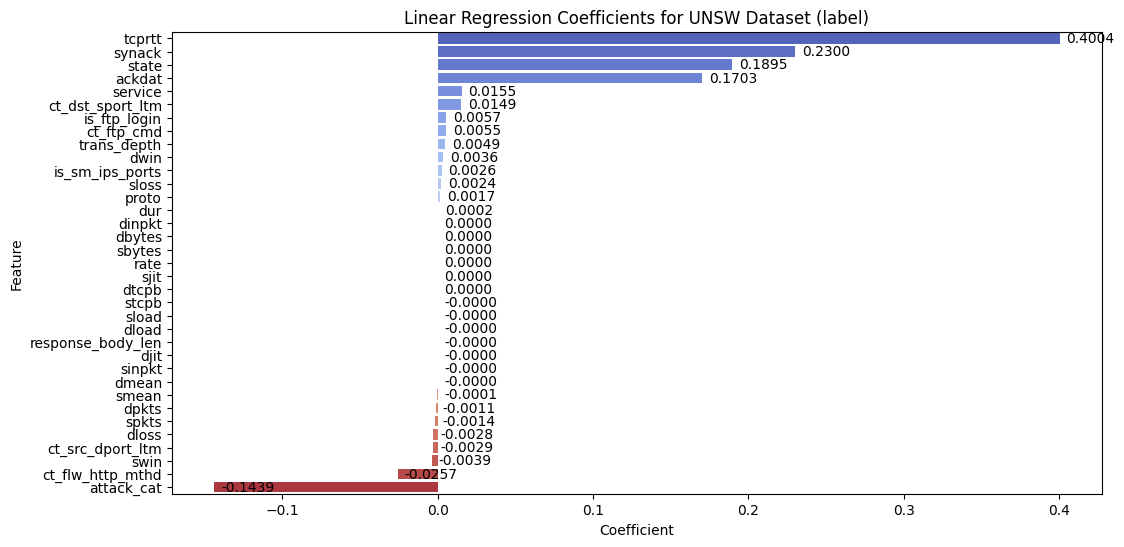

VIF for UNSW dataset:
               Feature           VIF
0                 dur  1.306043e+00
1               spkts  9.016615e+01
2               dpkts  3.548747e+02
3              sbytes  2.263727e+02
4              dbytes  2.439655e+02
5                rate  2.260663e+00
6               sload  1.976521e+00
7               dload  1.816006e+00
8               sloss  2.849199e+02
9               dloss  6.801116e+02
10             sinpkt  1.078717e+01
11             dinpkt  2.074393e+00
12               sjit  2.277768e+00
13               djit  1.474428e+00
14               swin  5.564855e+01
15              stcpb  4.029151e+00
16              dtcpb  4.014166e+00
17               dwin  6.159112e+01
18             tcprtt  8.188363e+14
19             synack  2.649176e+14
20             ackdat  1.916425e+14
21              smean  1.460091e+00
22              dmean  2.705849e+00
23        trans_depth  1.118230e+00
24  response_body_len  1.309616e+00
25   ct_src_dport_ltm  5.796660e+00
26   

In [18]:
# --- Single Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
# Collect coefficients
coef_df_unsw = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)
# Plot coefficients
plt.figure(figsize=(12,6))
ax = sns.barplot(data=coef_df_unsw, x="Coefficient", y="Feature", palette="coolwarm")
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}", 
                (p.get_width(), p.get_y() + p.get_height()/2),
                xytext=(5,0), textcoords="offset points",
                ha="left", va="center")
plt.title("Linear Regression Coefficients for UNSW Dataset (label)")
plt.show()


# --- Polynomial Regression ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_train)

lr_poly = LinearRegression()
lr_poly.fit(X_poly, y_train)
# --- Multicollinearity (VIF) ---
X_numeric = X_train.select_dtypes(include=[np.number])
vif_data_unsw = pd.DataFrame()
vif_data_unsw["Feature"] = X_numeric.columns
vif_data_unsw["VIF"] = [variance_inflation_factor(X_numeric.values, i)
                        for i in range(X_numeric.shape[1])]
print("VIF for UNSW dataset:\n", vif_data_unsw)

# --- Model Evaluation ---
rmse_unsw = np.sqrt(mean_squared_error(y_test, y_pred))
mae_unsw = mean_absolute_error(y_test, y_pred)
print(f"RMSE: {rmse_unsw:.4f}, MAE: {mae_unsw:.4f}")





# Conclusion
we applied linear regression to predict whether a connection was normal or malicious using both numeric and categorical features.
We applied linear regression (with polynomial/interaction terms) using the UNSW dataset to predict malicious vs. normal network activity. This helped us explore how different features (traffic rates, packet counts, delays, and protocol information) relate to the target.

The VIF analysis revealed very high multicollinearity in certain variables — especially spkts, dpkts, sbytes, dloss, and timing-related features (tcprtt, synack, ackdat). These extreme values (some >10¹⁴) indicate that many network flow variables are strongly correlated and may distort regression coefficients.

The evaluation metrics (RMSE ≈ 0.28, MAE ≈ 0.21) suggest that the linear regression fit the data reasonably in terms of numerical prediction. However, since the target is binary (attack vs. normal), these metrics don’t fully reflect classification performance.

Overall, while this exercise revealed feature relationships and multicollinearity patterns, linear regression is not the best choice for binary outcomes. For next steps, we should shift toward logistic regression, decision trees, or ensemble models that can better capture the classification nature of cyberattacks.